# One-time held-out check of the idea-grafting result: evaluation assembly (`eval.py`)

This notebook is the **evaluation-assembly step** of artifact `art_WZ8fbLn79nCq`. It evaluates the iteration-3 *D2 host-entry* result (art_2Cd2JJypeGuA), part of a study of how scientific concepts spread from one field into others (OpenAlex concept-subfield networks).

**Background.**
* **D2** asks whether a concept that enters a new *host* subfield gets taken up there more strongly when the entry papers use more of the host's own vocabulary (regressor `A_cont`, "nativeness"). The effect is reported as an incidence-rate ratio per SD of the regressor (IRR/SD).
* The model was tuned on a **screen** fold. A sealed **held-out** fold was opened exactly **once** (`d2/open_once.sh`).
* **G1-G3** are supplementary checks for artefacts:
  * **G1:** is the effect driven by single papers rather than multi-team uptake?
  * **G2:** is it NATIVE or ADJACENT vocabulary share?
  * **G3:** is it absorbed by topic-classifier controls? Also includes a placebo host test.

**What `eval.py` does.** It reads the outputs of the staged scripts (fold regressions, placebo draws, audits) and then:
1. recounts the iteration-3 robustness grid by a declared rule (Step 4);
2. applies the frozen **mechanism rule** to the pooled G rows (artefact / grafting / host-vocabulary / unresolved);
3. writes `results/record_of_numbers.csv`: every reported number with its source and a SCREEN / CONFIRMATORY / SUPPLEMENTARY label;
4. draws figures F1-F4;
5. writes `eval_out.json` with 283 aggregate metrics plus two example datasets (`d2_heldout_events`, `g_rows`).

**Demo data.** `mini_demo_data.json` bundles every staged input file the script reads, plus a stratified subset of 100 of the 1,097 held-out events. The subset stratifies on field group × outcome. All aggregate metrics come from the bundled summary files, so they are identical to the full run. Only the size of the `d2_heldout_events` example dataset depends on the config below.

The code cells below are the original script, split into sections. The only change: the workspace `WS` points at a local folder that is rebuilt from the bundle, instead of at `Path(__file__)`.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib, pyarrow — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'pyarrow==18.1.0')

## Imports
The original import block of `eval.py`, plus `IPython.display` for showing the saved figures at the end.

In [2]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger

# notebook-only addition (display saved figures / tables)
from IPython.display import Image, display

## Data loading
Load `mini_demo_data.json` from GitHub, falling back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-4/evaluation-2/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"{len(data['files'])} staged input files; {len(data['heldout_event_predictions'])} of "
      f"{data['n_heldout_events_full']} held-out events bundled")

Inputs of eval.py (art_WZ8fbLn79nCq): the staged result files it reads (JSON parsed, CSV/text verbatim) plus a stratified 100-row subset of results/heldout_event_predictions.parquet (1,097 held-out events in full).
22 staged input files; 100 of 1097 held-out events bundled


## Config
There is only one scale knob. `N_HELDOUT_EVENTS` sets how many held-out events go into the `d2_heldout_events` example dataset. The bundle holds 100. The original run used all 1,097 from `results/heldout_event_predictions.parquet`.

The script does no fitting: the regressions, 200-draw placebo and 500-draw permutation were done by earlier staged scripts. Their outputs are bundled, so no other parameter changes the runtime.

In [5]:
N_HELDOUT_EVENTS = 100   # held-out events written to d2_heldout_events (max 100 in the bundle; original run: all 1097)
WS_DIR = "eval_ws"         # local stand-in for the artifact workspace (original: the folder containing eval.py)

## Rebuild the workspace layout from the bundle
`eval.py` reads files at fixed paths under its workspace: `results/`, `d2/results/` and `audit/`. This cell writes the bundled files back to those paths so the original functions run unchanged:
* JSON files are re-serialised.
* CSV and text files are written verbatim.
* The held-out event table goes back to parquet, cut to `N_HELDOUT_EVENTS` rows.

In [6]:
_ws = Path(WS_DIR)
for rel, f in data["files"].items():
    p = _ws / rel
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text(json.dumps(f["content"], indent=1) if f["kind"] == "json" else f["content"])
pd.DataFrame(data["heldout_event_predictions"][:N_HELDOUT_EVENTS]).to_parquet(_ws / "results" / "heldout_event_predictions.parquet")
print(sorted(str(p.relative_to(_ws)) for p in _ws.rglob("*") if p.is_file()))

['audit/audit_headline.json', 'audit/audit_perm.json', 'd2/heldout_spec.sha256', 'd2/results/HELDOUT_OPENED.lock', 'd2/results/d2_robustness.csv', 'd2/results/heldout_confirmation.json', 'd2/results/heldout_dryrun_on_screen.json', 'results/g_heldout_rows.csv', 'results/g_heldout_summary.json', 'results/g_placebo_host_draws_heldout.csv', 'results/g_placebo_host_draws_pooled.csv', 'results/g_placebo_host_draws_screen.csv', 'results/g_pooled_rows.csv', 'results/g_pooled_summary.json', 'results/g_screen_rows.csv', 'results/g_screen_summary.json', 'results/g_spec.json', 'results/g_spec.sha256', 'results/gate_hashes.json', 'results/gate_r0c.json', 'results/heldout_event_predictions.parquet', 'results/heldout_post.json', 'results/heldout_robustness.csv']


## Workspace paths and logging
The original setup block. `WS` now points at the rebuilt folder; `Path(__file__)` does not exist inside a notebook.

In [7]:
WS = Path(WS_DIR).resolve()  # original: Path(__file__).resolve().parent
RES, FIGS, D2 = WS / "results", WS / "figures", WS / "d2"
RUN_REL = "3_invention_loop/iter_4/gen_art/gen_art_evaluation_2"  # this workspace relative to the run root
FIGS.mkdir(exist_ok=True)
(WS / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(WS / "logs" / "eval.log", rotation="30 MB", level="DEBUG")

2

## Small helpers
* `jload` reads JSON, returning `None` if the file is missing.
* `num` coerces a value to a finite float, or `None`.
* `degenerate` flags separation-like fits as *not interpretable*: IRR < 0.01 or > 100, a CI lower bound ≤ 0, or a CI ratio > 50. This is a post-hoc display flag, not a change to the spec.

In [8]:
def jload(p: Path) -> dict | None:
    return json.loads(p.read_text()) if p.exists() else None


def degenerate(lo, hi, v) -> bool:
    """Post-hoc flag (not a spec change): separation-like fits with an exploding IRR or CI are not interpretable."""
    lo, hi, v = num(lo), num(hi), num(v)
    if v is None or lo is None or hi is None:
        return False
    return bool(v < 0.01 or v > 100 or lo <= 0 or hi / max(lo, 1e-300) > 50)


def num(x) -> float | None:
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    return v if np.isfinite(v) else None

## Step 4: recount the iteration-3 robustness grid
Iteration 3 had reported "26/27 significant co-primary rows". This recount applies a declared rule to `d2/results/d2_robustness.csv`:
* A row is **significant** if `irr_sd_A_lo > 1` and `p_A < 0.05`.
* Rows are counted separately for each FE spec: `secondary` (the co-primary) and `primary`.
* The null rows are listed explicitly.
* Degenerate fits count toward the totals but are excluded from the reported IRR range.

In [9]:
# ------------------------------------------------------------------------------------------------ Step 4 recount
def robustness_recount() -> dict:
    r = pd.read_csv(D2 / "results" / "d2_robustness.csv")
    out = {"rule": "rows with a non-null irr_sd_A; significant = irr_sd_A_lo > 1 AND p_A < 0.05; counted per FE spec; "
                   "second denominator excludes the base row 'PRIMARY (MAIN)' and the 3 descriptive field-group strata; "
                   "IRR range over significant rows excludes the A_cont_hi bound (different scale)",
           "source": "3_invention_loop/iter_3/gen_art/gen_art_experiment_7/results/d2_robustness.csv"}
    for fe in ("secondary", "primary"):
        x = r[(r.fe == fe) & r.irr_sd_A.notna()].copy()
        x["sig"] = (x.irr_sd_A_lo > 1) & (x.p_A < 0.05)
        ex = x[~x.spec.str.startswith("PRIMARY (MAIN)") & ~x.spec.str.contains("descriptive")]
        x["degenerate"] = [degenerate(a, b, c) for a, b, c in zip(x.irr_sd_A_lo, x.irr_sd_A_hi, x.irr_sd_A)]
        rng = x[x.sig & ~x.spec.str.contains("A_cont_hi") & ~x.degenerate]
        out[fe] = {"n_rows_with_A": int(len(x)), "n_significant": int(x.sig.sum()),
                   "n_rows_excl_base_and_strata": int(len(ex)), "n_significant_excl_base_and_strata": int(ex.sig.sum()),
                   "irr_range_significant_excl_hi_bound": [num(rng.irr_sd_A.min()), num(rng.irr_sd_A.max())],
                   "null_rows": [{"spec": s.spec, "irr_sd_A": num(s.irr_sd_A), "ci": [num(s.irr_sd_A_lo), num(s.irr_sd_A_hi)],
                                  "p_A": num(s.p_A), "N": num(s.N), "G": num(s.G)} for s in x[~x.sig].itertuples()],
                   "degenerate_rows (counted above, excluded from the IRR range)": x[x.degenerate].spec.tolist(),
                   "n_significant_non_degenerate": int((x.sig & ~x.degenerate).sum()),
                   "rows_without_A_or_failed": [s for s in r[(r.fe == fe) & r.irr_sd_A.isna()].spec.tolist()]}
    (RES / "robustness_recount.json").write_text(json.dumps(out, indent=1))
    return out

## The frozen mechanism rule
This cell applies the rule frozen in `results/g_spec.json` to the pooled G rows.

The result is labelled **artefact** only if all of these hold:
* G1 multi-team is small (IRR < 1.10) and its CI includes 1;
* the projected MDE is ≤ 1.20;
* G3 combined controls remove > 50 % of the log-IRR;
* G ≥ 30.

Otherwise, the label follows the G2a reading: grafting, host-vocabulary, or unresolved.

In [10]:
# ------------------------------------------------------------------------------------------------ mechanism label
def mechanism_label(spec: dict) -> dict | None:
    ps = jload(RES / "g_pooled_summary.json")
    if ps is None:
        return None
    rows = pd.read_csv(RES / "g_pooled_rows.csv")
    g1 = rows[(rows.row == "G1-multi (co-primary FE)") & (rows["var"] == "A_cont")].iloc[0]
    mde = spec["mde"]["G1_multi_pooled_projected"]["MDE_irr_sd_power80"]
    g1_null = not (g1.irr_sd_lo > 1 or g1.irr_sd_hi < 1)
    g1_small = g1.irr_sd < 1.10 and g1_null
    pct = ps["G3_pct"]["G3(combined)"]["pct"]
    art = bool(g1_small and mde is not None and mde <= 1.20 and pct is not None and pct > 50 and g1.G >= 30)
    g2 = ps["G2a"]["reading"]
    if art:
        label = "artefact"
    elif g2.startswith("grafting"):
        label = "grafting"
    elif g2.startswith("host-vocabulary"):
        label = "host-vocabulary"
    else:
        label = "unresolved"
    out = {"label": label, "scope": "pooled screen + held-out; partially pre-specified (held-out G rows were not in the "
                                    "frozen heldout_spec; screen G rows were not blind)",
           "inputs": {"G1_multi_irr_sd": g1.irr_sd, "G1_multi_ci": [g1.irr_sd_lo, g1.irr_sd_hi], "G1_multi_G": int(g1.G),
                      "G1_mde_pooled_projected": mde, "G1_status": ps["G1_status"]["label"],
                      "G3_combined_pct_logirr_removed": pct,
                      "G3_combined_pct_ci": ps["G3_pct"]["G3(combined)"].get("ci95"), "G2a_reading": g2,
                      "G2a_NAT": {k: ps["G2a"]["NAT"].get(k) for k in ("irr_sd", "irr_sd_lo", "irr_sd_hi", "p")},
                      "G2a_ADJ": {k: ps["G2a"]["ADJ"].get(k) for k in ("irr_sd", "irr_sd_lo", "irr_sd_hi", "p")}},
           "artefact_conditions": {"G1_multi_irr_lt_1.10_and_ci_includes_1": bool(g1_small),
                                   "G1_mde_le_1.20": bool(mde is not None and mde <= 1.20),
                                   "G3_combined_removes_gt_50pct": bool(pct is not None and pct > 50),
                                   "G1_G_ge_30": bool(g1.G >= 30)},
           "placebo_host_qualifier": {k: {"PASS": v["PASS"], "share_pos_sig": v["share_pos_sig"],
                                          "median_irr_sd": v["placebo_irr_sd_median"]}
                                      for k, v in ps["placebo_host"].items()},
           "rule": spec["definitions"]["mechanism_rule"]}
    (RES / "mechanism_label.json").write_text(json.dumps(out, indent=1, default=float))
    return out

## Record of numbers
Builds one row per reported number: the fold G rows, the D2 held-out confirmation, the screen dry-run reproduction, the held-out robustness rows and the recount. Each row records its source path and label:
* **SCREEN**: not blind.
* **CONFIRMATORY**: frozen spec rows on the held-out fold.
* **SUPPLEMENTARY**: G rows on held-out or pooled data.

In [11]:
# ------------------------------------------------------------------------------------------------ record
def record(conf: dict | None, post: dict | None, rec: dict) -> pd.DataFrame:
    recs = []
    lab = {"screen": "SCREEN", "heldout": "SUPPLEMENTARY", "pooled": "SUPPLEMENTARY"}
    for fold in ("screen", "heldout", "pooled"):
        p = RES / f"g_{fold}_rows.csv"
        if not p.exists():
            continue
        for r in pd.read_csv(p).itertuples():
            if pd.isna(getattr(r, "irr_sd", np.nan)):
                continue
            dg = " [DEGENERATE FIT: not interpretable]" if degenerate(r.irr_sd_lo, r.irr_sd_hi, r.irr_sd) else ""
            recs.append({"number": f"{r.row} | {r.var} IRR/SD{dg}", "value": r.irr_sd, "CI": f"[{r.irr_sd_lo:.4g}, {r.irr_sd_hi:.4g}]",
                         "p": r.p, "p_wild": getattr(r, "p_wild", None), "N": r.N, "G": r.G, "spec": r.spec,
                         "source_path": f"{RUN_REL}/results/g_{fold}_rows.csv", "fold": fold, "label": lab[fold]})
    if conf:
        for sp in ("primary", "secondary"):
            r = conf.get(sp)
            if not r:
                continue
            for v in ("A_cont", "CT"):
                ci = r["ci_irr_sd"][v]
                recs.append({"number": f"D2 held-out {sp} {v} IRR/SD", "value": r["irr_sd"][v],
                             "CI": f"[{ci[0]:.4f}, {ci[1]:.4f}]", "p": r["p"][v], "p_wild": r["p_wild"][v],
                             "N": r["n_retained"], "G": r["G"], "spec": sp,
                             "source_path": f"{RUN_REL}/d2/results/heldout_confirmation.json", "fold": "heldout",
                             "label": "CONFIRMATORY"})
    scr = jload(D2 / "results" / "heldout_dryrun_on_screen.json")
    for sp in ("primary", "secondary"):
        r = scr[sp]
        ci = r["ci_irr_sd"]["A_cont"]
        recs.append({"number": f"D2 screen {sp} A_cont IRR/SD (dry-run reproduction)", "value": r["irr_sd"]["A_cont"],
                     "CI": f"[{ci[0]:.4f}, {ci[1]:.4f}]", "p": r["p"]["A_cont"], "p_wild": r["p_wild"]["A_cont"],
                     "N": r["n_retained"], "G": r["G"], "spec": sp,
                     "source_path": f"{RUN_REL}/d2/results/heldout_dryrun_on_screen.json", "fold": "screen",
                     "label": "SCREEN"})
    if post is not None and Path(RES / "heldout_robustness.csv").exists():
        for r in pd.read_csv(RES / "heldout_robustness.csv").itertuples():
            if pd.isna(getattr(r, "irr_sd_A", np.nan)):
                continue
            recs.append({"number": f"held-out robustness: {r.spec} A IRR/SD", "value": r.irr_sd_A,
                         "CI": f"[{r.irr_sd_A_lo:.4f}, {r.irr_sd_A_hi:.4f}]", "p": r.p_A, "p_wild": None, "N": r.N,
                         "G": r.G, "spec": r.fe, "source_path": f"{RUN_REL}/results/heldout_robustness.csv",
                         "fold": "heldout", "label": "CONFIRMATORY"})
    for fe in ("secondary", "primary"):
        recs.append({"number": f"iteration-3 robustness recount ({fe}): significant rows", "value": rec[fe]["n_significant"],
                     "CI": f"of {rec[fe]['n_rows_with_A']} rows with an A term", "p": None, "p_wild": None, "N": None,
                     "G": None, "spec": fe, "source_path": f"{RUN_REL}/results/robustness_recount.json",
                     "fold": "screen", "label": "SCREEN"})
    df = pd.DataFrame(recs)
    df.to_csv(RES / "record_of_numbers.csv", index=False)
    return df

## Figures F1-F4
* **F1:** forest plot of screen vs held-out vs pooled estimates for the D2 co-primary and primary rows and the G1-G3 rows.
* **F2:** G2a threshold heatmaps for NATIVE and ADJACENT shares.
* **F3:** placebo-host IRR distributions against the observed `A_cont`.
* **F4:** G1 multi-team vs single-paper entries.

They are written to `eval_ws/figures/` (PNG and PDF) and shown at the end of the notebook.

In [12]:
# ------------------------------------------------------------------------------------------------ figures
def figures(conf: dict | None, spec: dict) -> list[str]:
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import matplotlib.ticker
    plt.rcParams.update({"font.size": 9, "pdf.fonttype": 42})
    col = {"screen": "#4C72B0", "heldout": "#DD8452", "pooled": "#55A868"}
    made = []
    tabs = {f: pd.read_csv(RES / f"g_{f}_rows.csv") for f in ("screen", "heldout", "pooled") if (RES / f"g_{f}_rows.csv").exists()}
    if not tabs:
        return made
    # F1 forest
    keys = [("G1-multi (co-primary FE)", "A_cont"), ("G1-multi, MAIN only", "A_cont"), ("G1-single complement", "A_cont"),
            ("G1-all-window", "A_cont"), ("G2a NATIVE+ADJACENT (native>=0.3, adjacent [0.05,0.3))", "NAT"),
            ("G2a NATIVE+ADJACENT (native>=0.3, adjacent [0.05,0.3))", "ADJ"),
            ("G3 base: co-primary (reports mean_topic_score = G3(i))", "A_cont"), ("G3(combined)", "A_cont"),
            ("G3 restriction: entry papers topic_score >= 0.9", "A_cont"),
            ("G3(iii) venue agreement (coverage-limited)", "A_cont"),
            ("G3(iv) outcome Y_strict_hc (W2 papers with topic_score >= 0.9)", "A_cont")]
    labels = ["G1 multi-team", "G1 multi-team, MAIN", "G1 single-paper", "G1 all window", "G2a NATIVE share",
              "G2a ADJACENT share", "Co-primary A_cont", "G3 combined controls", "G3 topic score >= 0.9",
              "G3(iii) venue (12% cov.)", "G3(iv) outcome topic >= 0.9"]
    fig, ax = plt.subplots(figsize=(7.2, 6.4))
    y0 = 0
    yt, yl = [], []
    if conf:
        for sp, nm in (("secondary", "D2 co-primary (frozen)"), ("primary", "D2 primary (frozen)")):
            sc = jload(D2 / "results" / "heldout_dryrun_on_screen.json")[sp]
            for k, (src, f) in enumerate(((sc, "screen"), (conf.get(sp), "heldout"))):
                if src:
                    v, (lo, hi) = src["irr_sd"]["A_cont"], src["ci_irr_sd"]["A_cont"]
                    ax.errorbar(v, y0 + 0.25 * k, xerr=[[v - lo], [hi - v]], fmt="o", color=col[f], ms=4, capsize=2)
            yt.append(y0 + 0.12)
            yl.append(nm)
            y0 += 1
    for (rw, var), nm in zip(keys, labels):
        for k, f in enumerate(("screen", "heldout", "pooled")):
            if f not in tabs:
                continue
            t = tabs[f]
            x = t[(t.row == rw) & (t["var"] == var)]
            if len(x) and pd.notna(x.irr_sd.iloc[0]):
                v, lo, hi = x.irr_sd.iloc[0], x.irr_sd_lo.iloc[0], x.irr_sd_hi.iloc[0]
                if degenerate(lo, hi, v):
                    ax.text(0.52, y0 + 0.25 * k, f"{f}: degenerate fit", color=col[f], fontsize=6, va="center")
                    continue
                ax.errorbar(v, y0 + 0.25 * k, xerr=[[v - lo], [hi - v]], fmt="o", color=col[f], ms=4, capsize=2)
            elif f in tabs:
                ax.text(0.52, y0 + 0.25 * k, f"{f}: fit failed", color=col[f], fontsize=6, va="center")
        yt.append(y0 + 0.25)
        yl.append(nm)
        y0 += 1
    ax.axvline(1, color="grey", lw=0.8, ls="--")
    ax.set_yticks(yt)
    ax.set_yticklabels(yl)
    ax.invert_yaxis()
    ax.set_xscale("log")
    ax.set_xlim(0.5, 3.5)
    ax.set_xticks([0.5, 0.75, 1, 1.5, 2, 3])
    ax.set_xticklabels(["0.5", "0.75", "1", "1.5", "2", "3"])
    ax.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
    ax.set_xlabel("IRR per SD of the regressor (95% CI, log scale)")
    for f in col:
        ax.plot([], [], "o", color=col[f], label=f)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
    ax.set_title("Screen vs held-out vs pooled: D2 co-primary and G1-G3 rows")
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(FIGS / f"F1_forest_screen_heldout_pooled.{ext}", dpi=200)
    plt.close(fig)
    made.append("figures/F1_forest_screen_heldout_pooled.png")
    # F2 G2 heatmap
    folds = [f for f in ("screen", "pooled") if f in tabs]
    fig, axes = plt.subplots(len(folds), 2, figsize=(8, 3.4 * len(folds)), squeeze=False,
                             gridspec_kw={"wspace": 0.45, "hspace": 0.45})
    P = spec["parameters"]
    for i, f in enumerate(folds):
        t = tabs[f]
        t = t[t.row.str.startswith("G2a")]
        for j, var in enumerate(("NAT", "ADJ")):
            M = np.full((3, 3), np.nan)
            S = np.full((3, 3), "", dtype=object)
            for a, nc in enumerate(P["g2_native_cuts"]):
                for b, al in enumerate(P["g2_adjacent_lower_cuts"]):
                    x = t[(t.nat_cut == nc) & (t.adj_lo == al) & (t["var"] == var)]
                    if len(x) and pd.notna(x.irr_sd.iloc[0]):
                        M[a, b] = x.irr_sd.iloc[0]
                        S[a, b] = f"{x.irr_sd.iloc[0]:.2f}\n[{x.irr_sd_lo.iloc[0]:.2f},{x.irr_sd_hi.iloc[0]:.2f}]"
            ax = axes[i, j]
            im = ax.imshow(M, cmap="RdBu_r", vmin=0.5, vmax=1.5)
            for a in range(3):
                for b in range(3):
                    dark = np.isfinite(M[a, b]) and M[a, b] > 1.33
                    ax.text(b, a, S[a, b], ha="center", va="center", fontsize=7, color="white" if dark else "black")
            ax.set_xticks(range(3))
            ax.set_xticklabels([str(x) for x in P["g2_adjacent_lower_cuts"]])
            ax.set_yticks(range(3))
            ax.set_yticklabels([str(x) for x in P["g2_native_cuts"]])
            ax.set_xlabel("adjacent lower cut")
            ax.set_ylabel("native cut")
            ax.set_title(f"{f}: {'NATIVE' if var == 'NAT' else 'ADJACENT'} share IRR/SD")
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7)
    for ext in ("png", "pdf"):
        fig.savefig(FIGS / f"F2_G2_threshold_heatmap.{ext}", dpi=200)
    plt.close(fig)
    made.append("figures/F2_G2_threshold_heatmap.png")
    # F3 placebo host
    fs = [f for f in ("screen", "heldout", "pooled") if (RES / f"g_placebo_host_draws_{f}.csv").exists()]
    fig, axes = plt.subplots(1, len(fs), figsize=(3.4 * len(fs), 2.9), squeeze=False)
    for i, f in enumerate(fs):
        d = pd.read_csv(RES / f"g_placebo_host_draws_{f}.csv")
        ax = axes[0, i]
        for strat, c in (("size", "#4C72B0"), ("prox", "#C44E52")):
            v = d[(d.strat == strat) & d.plac_ok].plac_irr_sd_plac
            ax.hist(v, bins=20, alpha=0.6, color=c, label=f"placebo host ({strat} decile)")
        t = tabs[f]
        obs = t[(t.row.str.startswith("G3 base")) & (t["var"] == "A_cont")].irr_sd.iloc[0]
        ax.axvline(obs, color="k", lw=1.2, label=f"observed A_cont {obs:.2f}")
        ax.axvline(1, color="grey", ls="--", lw=0.8)
        ax.set_title(f"{f}")
        ax.set_xlabel("IRR per SD")
        if i == 0:
            ax.legend(fontsize=6, frameon=False)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(FIGS / f"F3_placebo_host.{ext}", dpi=200)
    plt.close(fig)
    made.append("figures/F3_placebo_host.png")
    # F4 G1 multi vs single
    fig, ax = plt.subplots(figsize=(6, 2.8))
    rws = [("G1-multi (co-primary FE)", "multi-team"), ("G1-multi, MAIN only", "multi-team MAIN"),
           ("G1-single complement", "single / same team"), ("G1-all-window", "all window entries")]
    for j, (rw, nm) in enumerate(rws):
        for k, f in enumerate(("screen", "heldout", "pooled")):
            if f not in tabs:
                continue
            x = tabs[f][(tabs[f].row == rw) & (tabs[f]["var"] == "A_cont")]
            if len(x) and pd.notna(x.irr_sd.iloc[0]):
                v, lo, hi = x.irr_sd.iloc[0], x.irr_sd_lo.iloc[0], x.irr_sd_hi.iloc[0]
                ax.errorbar(j + 0.2 * (k - 1), v, yerr=[[v - lo], [hi - v]], fmt="o", color=col[f], ms=4, capsize=2,
                            label=f if j == 0 else None)
    ax.axhline(1, color="grey", ls="--", lw=0.8)
    ax.set_xticks(range(len(rws)))
    ax.set_xticklabels([n for _, n in rws])
    ax.set_ylabel("A_cont IRR per SD")
    ax.set_title("G1: two-year entry window, multi-team vs single-paper entries")
    ax.legend(frameon=False, fontsize=7)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(FIGS / f"F4_G1_multi_vs_single.{ext}", dpi=200)
    plt.close(fig)
    made.append("figures/F4_G1_multi_vs_single.png")
    return made

## Example datasets and output variants
* `g_row_examples` turns every fold G-row regression into an input/output example.
* `heldout_examples` turns each held-out event into an example: its features, the observed strict uptake count `Y_strict`, and the screen-fit predictions with and without `A_cont` (`mu1` and `mu0`). It also records their Poisson deviances and the deviance gain.
* `write_variants` writes the full, mini and preview JSON files.

In [13]:
# ------------------------------------------------------------------------------------------------ eval_out
def g_row_examples() -> list[dict]:
    ex = []
    for fold in ("screen", "heldout", "pooled"):
        p = RES / f"g_{fold}_rows.csv"
        if not p.exists():
            continue
        for r in pd.read_csv(p).to_dict("records"):
            inp = {k: r.get(k) for k in ("row", "fold", "spec", "y", "var", "test", "nat_cut", "adj_lo") if pd.notna(r.get(k))}
            outp = {k: num(r.get(k)) for k in ("b", "se", "p", "irr_sd", "irr_sd_lo", "irr_sd_hi", "irr_01", "p_wild",
                                              "p_placebo_cal", "p_holm_G", "N", "G", "retained_share", "N_input")}
            e = {"input": json.dumps(inp), "output": json.dumps(outp),
                 "metadata_fold": fold, "metadata_label": "SCREEN" if fold == "screen" else "SUPPLEMENTARY",
                 "metadata_row": r["row"], "metadata_var": r["var"]}
            for k in ("irr_sd", "irr_sd_lo", "irr_sd_hi", "p", "p_wild", "p_placebo_cal", "N", "G"):
                v = num(r.get(k))
                if v is not None:
                    e[f"eval_{k}"] = v
            e["eval_ci_excludes_1"] = float(num(r.get("irr_sd_lo")) is not None and
                                            (r["irr_sd_lo"] > 1 or r["irr_sd_hi"] < 1))
            e["eval_degenerate_fit"] = float(degenerate(r.get("irr_sd_lo"), r.get("irr_sd_hi"), r.get("irr_sd")))
            ex.append(e)
    return ex


def heldout_examples() -> list[dict]:
    p = RES / "heldout_event_predictions.parquet"
    if not p.exists():
        return []
    te = pd.read_parquet(p)
    feats = ["A_cont", "CT", "prox_od", "RD", "log_n_partner_tags", "cov", "demic", "mean_topic_score",
             "boundary_share", "abstract_share", "mom_d", "log_centrality", "log_W1", "n_entry_papers"]
    ex = []
    for r in te.itertuples():
        inp = {"concept_id": r.concept_id, "host_subfield_d": int(r.d), "entry_year_e": int(r.e),
               "origin_subfield_o": int(r.o), **{f: num(getattr(r, f)) for f in feats}}
        ex.append({"input": json.dumps(inp), "output": str(int(r.Y_strict)),
                   "predict_coprimary_screen_fit": f"{r.mu1:.6f}", "predict_controls_only": f"{r.mu0:.6f}",
                   "metadata_concept_id": r.concept_id, "metadata_fold": "heldout",
                   "metadata_field_group": r.field_group,
                   "eval_poisson_deviance_coprimary_screen_fit": float(r.dev1),
                   "eval_poisson_deviance_controls_only": float(r.dev0),
                   "eval_deviance_gain": float(r.dev0 - r.dev1)})
    return ex


def _trunc(x, n: int = 200):
    if isinstance(x, str):
        return x[:n]
    if isinstance(x, dict):
        return {k: _trunc(v, n) for k, v in x.items()}
    if isinstance(x, list):
        return [_trunc(v, n) for v in x]
    return x


def write_variants(out: dict) -> None:
    """full = eval_out.json; mini = first 3 examples per dataset; preview = mini with strings cut to 200 chars."""
    (WS / "full_eval_out.json").write_text(json.dumps(out, indent=1, default=float))
    mini = {**out, "datasets": [{**d, "examples": d["examples"][:3]} for d in out["datasets"]]}
    (WS / "mini_eval_out.json").write_text(json.dumps(mini, indent=1, default=float))
    prev = {"metadata": _trunc(out["metadata"]), "metrics_agg": out["metrics_agg"],
            "datasets": [{"dataset": d["dataset"], "examples": _trunc(d["examples"][:3])} for d in out["datasets"]]}
    (WS / "preview_eval_out.json").write_text(json.dumps(prev, indent=1, default=float))

## `main()`: assemble `eval_out.json`
`main` runs the steps above, then collects the aggregate metrics:
* gates R0a, R0b and R0c;
* the held-out co-primary and primary IRRs, with Holm, wild-bootstrap, placebo-calibrated and permutation p-values;
* out-of-sample deviance, heterogeneity, and held-out robustness counts;
* per-fold G1, G2 and G3 rows, the placebo host, and the independent pyfixest audit numbers;
* the robustness recount and the mechanism label.

It then writes `eval_out.json` and its variants.

In [14]:
def main() -> None:
    spec = jload(RES / "g_spec.json")
    conf = jload(D2 / "results" / "heldout_confirmation.json")
    post = jload(RES / "heldout_post.json")
    gates = {"R0a": jload(RES / "gate_hashes.json"), "R0c": jload(RES / "gate_r0c.json")}
    rec = robustness_recount()
    mech = mechanism_label(spec) if spec else None
    rn = record(conf, post, rec)
    figs = figures(conf, spec) if spec else []
    M: dict[str, float] = {}

    def put(k, v):
        v = num(v)
        if v is not None:
            M[k] = v

    put("gate_R0a_all_hashes_match", float(bool(gates["R0a"] and gates["R0a"]["all_match"])))
    put("gate_R0c_pass", float(bool(gates["R0c"] and gates["R0c"]["pass"])))
    dry = jload(D2 / "results" / "heldout_dryrun_on_screen.json")
    put("gate_R0b_screen_coprimary_irr_sd", dry["secondary"]["irr_sd"]["A_cont"])
    put("gate_R0b_pass", float(abs(dry["secondary"]["irr_sd"]["A_cont"] - 1.300) < 5e-4 and dry["secondary"]["n_retained"] == 1544
                               and dry["secondary"]["G"] == 140 and dry["primary"]["n_retained"] == 452))
    if conf:
        for sp, tag in (("secondary", "coprimary"), ("primary", "primary")):
            r = conf.get(sp)
            if r:
                put(f"heldout_{tag}_irr_sd", r["irr_sd"]["A_cont"])
                put(f"heldout_{tag}_ci_lo", r["ci_irr_sd"]["A_cont"][0])
                put(f"heldout_{tag}_ci_hi", r["ci_irr_sd"]["A_cont"][1])
                put(f"heldout_{tag}_p", r["p"]["A_cont"])
                put(f"heldout_{tag}_p_wild", r["p_wild"]["A_cont"])
                put(f"heldout_{tag}_ct_irr_sd", r["irr_sd"]["CT"])
                put(f"heldout_{tag}_ct_p", r["p"]["CT"])
                put(f"heldout_{tag}_N", r["n_retained"])
                put(f"heldout_{tag}_G", r["G"])
                put(f"heldout_{tag}_retained_share", r["retained_share"])
            dec = conf.get(f"decision_{sp}")
            if dec:
                put(f"heldout_{tag}_holm_p_A", dec["holm_p"]["A_cont"])
                put(f"heldout_{tag}_reading_grafting", float(dec["reading"] == "GRAFTING"))
    if post:
        f = post["flags"]
        put("d2_dead", float(f["KILL_co_primary_dead"]))
        put("heldout_coprimary_confirmed", float(f["secondary"]["confirmed"]))
        put("heldout_primary_confirmed", float(f["primary"]["confirmed"]))
        put("heldout_primary_inconclusive_underpowered", float(f["primary_label"] == "inconclusive (underpowered)"))
        put("heldout_coprimary_p_placebo_cal", f["secondary"].get("p_placebo_cal_screenSD"))
        put("heldout_coprimary_p_placebo_cal_heldoutSD", f["secondary"].get("p_placebo_cal_heldoutSD"))
        h = f["secondary"].get("heterogeneity_screen_vs_heldout") or {}
        put("heterogeneity_screen_vs_heldout_p", h.get("p"))
        put("heterogeneity_b_diff", h.get("diff"))
        pp = post["nativeness_permutation_placebo"].get("secondary", {})
        put("heldout_perm_placebo_p_coprimary", pp.get("perm_p_two_sided_z"))
        put("heldout_perm_placebo_z_sd_coprimary", pp.get("placebo_z_sd"))
        put("heldout_oos_deviance_diff", post["oos"]["deviance_diff_with_minus_controls"])
        put("heldout_oos_deviance_diff_ci_lo", post["oos"]["ci95_concept_bootstrap"][0])
        put("heldout_oos_deviance_diff_ci_hi", post["oos"]["ci95_concept_bootstrap"][1])
        rb = pd.read_csv(RES / "heldout_robustness.csv")
        x = rb[(rb.fe == "secondary") & rb.irr_sd_A.notna() & ~rb.spec.str.contains("descriptive")]
        put("heldout_robustness_secondary_sig_count", ((x.irr_sd_A_lo > 1) & (x.p_A < 0.05)).sum())
        put("heldout_robustness_secondary_rows", len(x))
        put("d3_heldout_hash_match", float(post["d3_heldout_sha256"]["match"]))
    for fold in ("screen", "heldout", "pooled"):
        p = RES / f"g_{fold}_rows.csv"
        sm = jload(RES / f"g_{fold}_summary.json")
        if not p.exists() or sm is None:
            continue
        t = pd.read_csv(p)

        def g(row, var="A_cont", col="irr_sd"):
            x = t[(t.row == row) & (t["var"] == var)]
            return x[col].iloc[0] if len(x) and col in x else None

        for key, row, var in (("g1_multi", "G1-multi (co-primary FE)", "A_cont"), ("g1_multi_main", "G1-multi, MAIN only", "A_cont"),
                              ("g1_single", "G1-single complement", "A_cont"), ("g1_all_window", "G1-all-window", "A_cont"),
                              ("g1_bridge", "G1-bridge: iteration-3 row (partner window [e,e+1], W2 [e+2,e+6], entry-year controls)", "A_cont_v"),
                              ("g2_native", "G2a NATIVE+ADJACENT (native>=0.3, adjacent [0.05,0.3))", "NAT"),
                              ("g2_adjacent", "G2a NATIVE+ADJACENT (native>=0.3, adjacent [0.05,0.3))", "ADJ"),
                              ("g3_base", "G3 base: co-primary (reports mean_topic_score = G3(i))", "A_cont"),
                              ("g3_combined", "G3(combined)", "A_cont")):
            put(f"{fold}_{key}_irr_sd", g(row, var))
            put(f"{fold}_{key}_ci_lo", g(row, var, "irr_sd_lo"))
            put(f"{fold}_{key}_ci_hi", g(row, var, "irr_sd_hi"))
            put(f"{fold}_{key}_p", g(row, var, "p"))
            put(f"{fold}_{key}_G", g(row, var, "G"))
        put(f"{fold}_g1_multi_share", sm["G1_descriptive"]["share_multi"])
        put(f"{fold}_g1_mde", sm["G1_status"]["mde"])
        gi = sm.get("G1_interaction") or {}
        put(f"{fold}_g1_interaction_ratio", gi.get("ratio_irr_multi_over_single"))
        put(f"{fold}_g1_interaction_p", gi.get("p_interaction"))
        put(f"{fold}_g2_wald_equal_p", sm["G2a"]["wald_equal_per01"].get("p"))
        put(f"{fold}_g2_corr_nat_adj", sm["G2a"]["corr_NAT_ADJ"])
        put(f"{fold}_g2_reading_grafting", float(sm["G2a"]["reading"].startswith("grafting")))
        put(f"{fold}_g2_reading_host_vocabulary", float(sm["G2a"]["reading"].startswith("host-vocabulary")))
        for k, v in sm["G3_pct"].items():
            kk = {"G3(i+) + min_topic_score": "i_plus", "G3(ii) + host_topic_share + sec_host_share": "ii",
                  "G3(combined)": "combined", "G3(iii) + venue_d_share": "iii"}[k]
            put(f"{fold}_g3_{kk}_pct_logirr_removed", v.get("pct"))
            if v.get("ci95"):
                put(f"{fold}_g3_{kk}_pct_ci_lo", v["ci95"][0])
                put(f"{fold}_g3_{kk}_pct_ci_hi", v["ci95"][1])
        for strat, v in sm["placebo_host"].items():
            put(f"{fold}_placebo_host_{strat}_share_pos_sig", v["share_pos_sig"])
            put(f"{fold}_placebo_host_{strat}_median_irr_sd", v["placebo_irr_sd_median"])
            put(f"{fold}_placebo_host_{strat}_pass", float(v["PASS"]))
            put(f"{fold}_placebo_host_{strat}_joint_A_irr_sd_median", v.get("joint_A_cont_irr_sd_median"))
    # headline aliases requested by the plan
    for k_new, k_old in (("g1_multi_irr_sd", "pooled_g1_multi_irr_sd"), ("g1_mde", "pooled_g1_mde"),
                         ("g2_native_irr_sd", "pooled_g2_native_irr_sd"), ("g2_adjacent_irr_sd", "pooled_g2_adjacent_irr_sd"),
                         ("g3_combined_pct_logirr_removed", "pooled_g3_combined_pct_logirr_removed"),
                         ("placebo_host_share_sig", "pooled_placebo_host_size_share_pos_sig")):
        if k_old in M:
            M[k_new] = M[k_old]
    ap = jload(WS / "audit" / "audit_perm.json")  # independent pyfixest audit (audit/audit_perm.py)
    if ap:
        put("audit_heldout_within_concept_perm_p", ap["perm_p_two_sided"])
        put("audit_heldout_within_concept_perm_z_sd", ap["z_sd"])
        put("audit_heldout_shuffled_crv1_reject_rate", ap["share_crv1_p_lt_0.05"])
    ah = jload(WS / "audit" / "audit_headline.json")
    if ah:
        put("audit_heldout_coprimary_irr_sd_abs_diff", abs(ah["heldout_coprimary"]["rederived"]["irr_sd"] -
                                                           ah["heldout_coprimary"]["reported"]["irr_sd"]))
    put("robustness_sig_count", rec["secondary"]["n_significant"])
    put("robustness_denominator", rec["secondary"]["n_rows_with_A"])
    put("robustness_sig_count_excl_base_strata", rec["secondary"]["n_significant_excl_base_and_strata"])
    put("robustness_denominator_excl_base_strata", rec["secondary"]["n_rows_excl_base_and_strata"])
    put("robustness_primary_sig_count", rec["primary"]["n_significant"])
    put("robustness_primary_denominator", rec["primary"]["n_rows_with_A"])
    if mech:
        for lb in ("artefact", "grafting", "host-vocabulary", "unresolved"):
            M[f"mechanism_label_{lb.replace('-', '_')}"] = float(mech["label"] == lb)
    datasets = []
    he = heldout_examples()
    if he:
        datasets.append({"dataset": "d2_heldout_events", "examples": he})
    ge = g_row_examples()
    if ge:
        datasets.append({"dataset": "g_rows", "examples": ge})
    meta = {"evaluation_name": "D2 held-out confirmation (one look) + G1-G3 artefact tests",
            "evaluated_artifact": "art_2Cd2JJypeGuA (iter_3/gen_art/gen_art_experiment_7), vendored in d2/",
            "heldout_spec_sha256": (D2 / "heldout_spec.sha256").read_text().split()[0],
            "g_spec_sha256": (RES / "g_spec.sha256").read_text().split()[0] if (RES / "g_spec.sha256").exists() else None,
            "heldout_lock": (D2 / "results" / "HELDOUT_OPENED.lock").read_text() if (D2 / "results" / "HELDOUT_OPENED.lock").exists() else None,
            "mechanism_label": mech["label"] if mech else None,
            "heldout_flags": post["flags"] if post else None, "figures": figs,
            "labels": "SCREEN = screen fold (not blind); CONFIRMATORY = frozen heldout_spec rows on the held-out fold; "
                      "SUPPLEMENTARY = G rows on held-out / pooled (not pre-declared in heldout_spec)",
            "record_of_numbers": "results/record_of_numbers.csv", "n_record_rows": int(len(rn))}
    out = {"metadata": meta, "metrics_agg": M, "datasets": datasets}
    (WS / "eval_out.json").write_text(json.dumps(out, indent=1, default=float))
    write_variants(out)
    logger.info(f"eval_out.json: {len(M)} metrics, datasets {[(d['dataset'], len(d['examples'])) for d in datasets]}; "
                f"mechanism {meta['mechanism_label']}")

In [15]:
main()

12:34:47|INFO   |eval_out.json: 283 metrics, datasets [('d2_heldout_events', 100), ('g_rows', 162)]; mechanism host-vocabulary


## Results
Headline numbers from the generated `eval_out.json`, the recount, a view of the held-out example events, and the four figures.

In [16]:
out = json.loads((WS / "eval_out.json").read_text())
M = out["metrics_agg"]
rows = [
    ("CONFIRMATORY", "Held-out co-primary A_cont IRR/SD", "heldout_coprimary"),
    ("CONFIRMATORY", "Held-out primary FE A_cont IRR/SD", "heldout_primary"),
    ("SUPPLEMENTARY", "Pooled G1 multi-team entries", "pooled_g1_multi"),
    ("SUPPLEMENTARY", "Pooled G1 single-paper complement", "pooled_g1_single"),
    ("SUPPLEMENTARY", "Pooled G2a NATIVE share", "pooled_g2_native"),
    ("SUPPLEMENTARY", "Pooled G2a ADJACENT share", "pooled_g2_adjacent"),
    ("SUPPLEMENTARY", "Pooled G3 combined controls", "pooled_g3_combined"),
]
tab = []
for lab, name, k in rows:
    tab.append({"label": lab, "estimate": name, "IRR/SD": M.get(f"{k}_irr_sd"),
                "CI lo": M.get(f"{k}_ci_lo"), "CI hi": M.get(f"{k}_ci_hi"), "p": M.get(f"{k}_p"), "G": M.get(f"{k}_G")})
display(pd.DataFrame(tab).round(4))

print(f"Mechanism label: {out['metadata']['mechanism_label']}")
print(f"Gates: R0a={M['gate_R0a_all_hashes_match']:.0f}  R0b={M['gate_R0b_pass']:.0f}  R0c={M['gate_R0c_pass']:.0f}")
print(f"Held-out co-primary: p_wild={M['heldout_coprimary_p_wild']:.3f}, Holm={M['heldout_coprimary_holm_p_A']:.4f}, "
      f"placebo-calibrated={M['heldout_coprimary_p_placebo_cal']:.3f}, permutation={M['heldout_perm_placebo_p_coprimary']:.3f}; "
      f"confirmed={bool(M['heldout_coprimary_confirmed'])}, D2 dead={bool(M['d2_dead'])}")
print(f"Pooled G3 combined: {M['pooled_g3_combined_pct_logirr_removed']:.1f}% of the log-IRR removed")
print(f"Robustness recount (co-primary): {M['robustness_sig_count']:.0f}/{M['robustness_denominator']:.0f} significant; "
      f"primary FE: {M['robustness_primary_sig_count']:.0f}/{M['robustness_primary_denominator']:.0f}")
print(f"{len(M)} aggregate metrics; datasets: {[(d['dataset'], len(d['examples'])) for d in out['datasets']]}")

,label,estimate,IRR/SD,CI lo,CI hi,p,G
0,CONFIRMATORY,Held-out co-primary A_cont IRR/SD,1.1875,1.0566,1.3346,0.0045,74.0
1,CONFIRMATORY,Held-out primary FE A_cont IRR/SD,0.9819,0.7042,1.3691,0.9113,30.0
2,SUPPLEMENTARY,Pooled G1 multi-team entries,1.2809,1.1051,1.4846,0.0011,161.0
3,SUPPLEMENTARY,Pooled G1 single-paper complement,1.1488,1.0346,1.2755,0.0097,200.0
4,SUPPLEMENTARY,Pooled G2a NATIVE share,1.1138,1.0463,1.1856,0.0008,214.0
5,SUPPLEMENTARY,Pooled G2a ADJACENT share,1.3192,1.1953,1.4560,0.0000,214.0
6,SUPPLEMENTARY,Pooled G3 combined controls,1.2379,1.1283,1.3581,0.0000,214.0


Mechanism label: host-vocabulary
Gates: R0a=1  R0b=1  R0c=1
Held-out co-primary: p_wild=0.012, Holm=0.0090, placebo-calibrated=0.034, permutation=0.026; confirmed=True, D2 dead=False
Pooled G3 combined: -7.3% of the log-IRR removed
Robustness recount (co-primary): 20/26 significant; primary FE: 2/24
283 aggregate metrics; datasets: [('d2_heldout_events', 100), ('g_rows', 162)]


,count,mean,sum
field_group,,,
CS,32,1.329,42.537
Physics/Astro,18,-0.892,-16.063
other,50,0.125,6.248


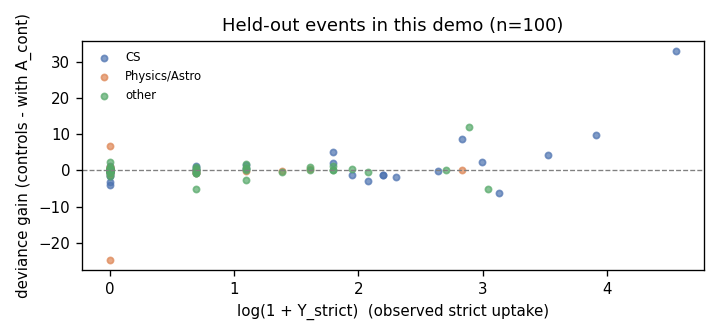

In [17]:

# Held-out example events in this demo: deviance gain from adding A_cont (screen-fit coefficients) per event
import matplotlib.pyplot as plt
he = next((d["examples"] for d in out["datasets"] if d["dataset"] == "d2_heldout_events"), [])
ev = pd.DataFrame([{"field_group": e["metadata_field_group"], "Y_strict": int(e["output"]),
                    "deviance_gain": e["eval_deviance_gain"]} for e in he])
display(ev.groupby("field_group").deviance_gain.agg(["count", "mean", "sum"]).round(3))
fig, ax = plt.subplots(figsize=(6, 2.8))
for g, c in zip(sorted(ev.field_group.unique()), ("#4C72B0", "#DD8452", "#55A868")):
    x = ev[ev.field_group == g]
    ax.scatter(np.log1p(x.Y_strict), x.deviance_gain, s=14, alpha=0.7, color=c, label=g)
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set_xlabel("log(1 + Y_strict)  (observed strict uptake)")
ax.set_ylabel("deviance gain (controls - with A_cont)")
ax.set_title(f"Held-out events in this demo (n={len(ev)})")
ax.legend(frameon=False, fontsize=7)
fig.tight_layout()
fig.savefig(FIGS / "demo_heldout_deviance_gain.png", dpi=120)
plt.close(fig)
display(Image(str(FIGS / "demo_heldout_deviance_gain.png")))


figures/F1_forest_screen_heldout_pooled.png


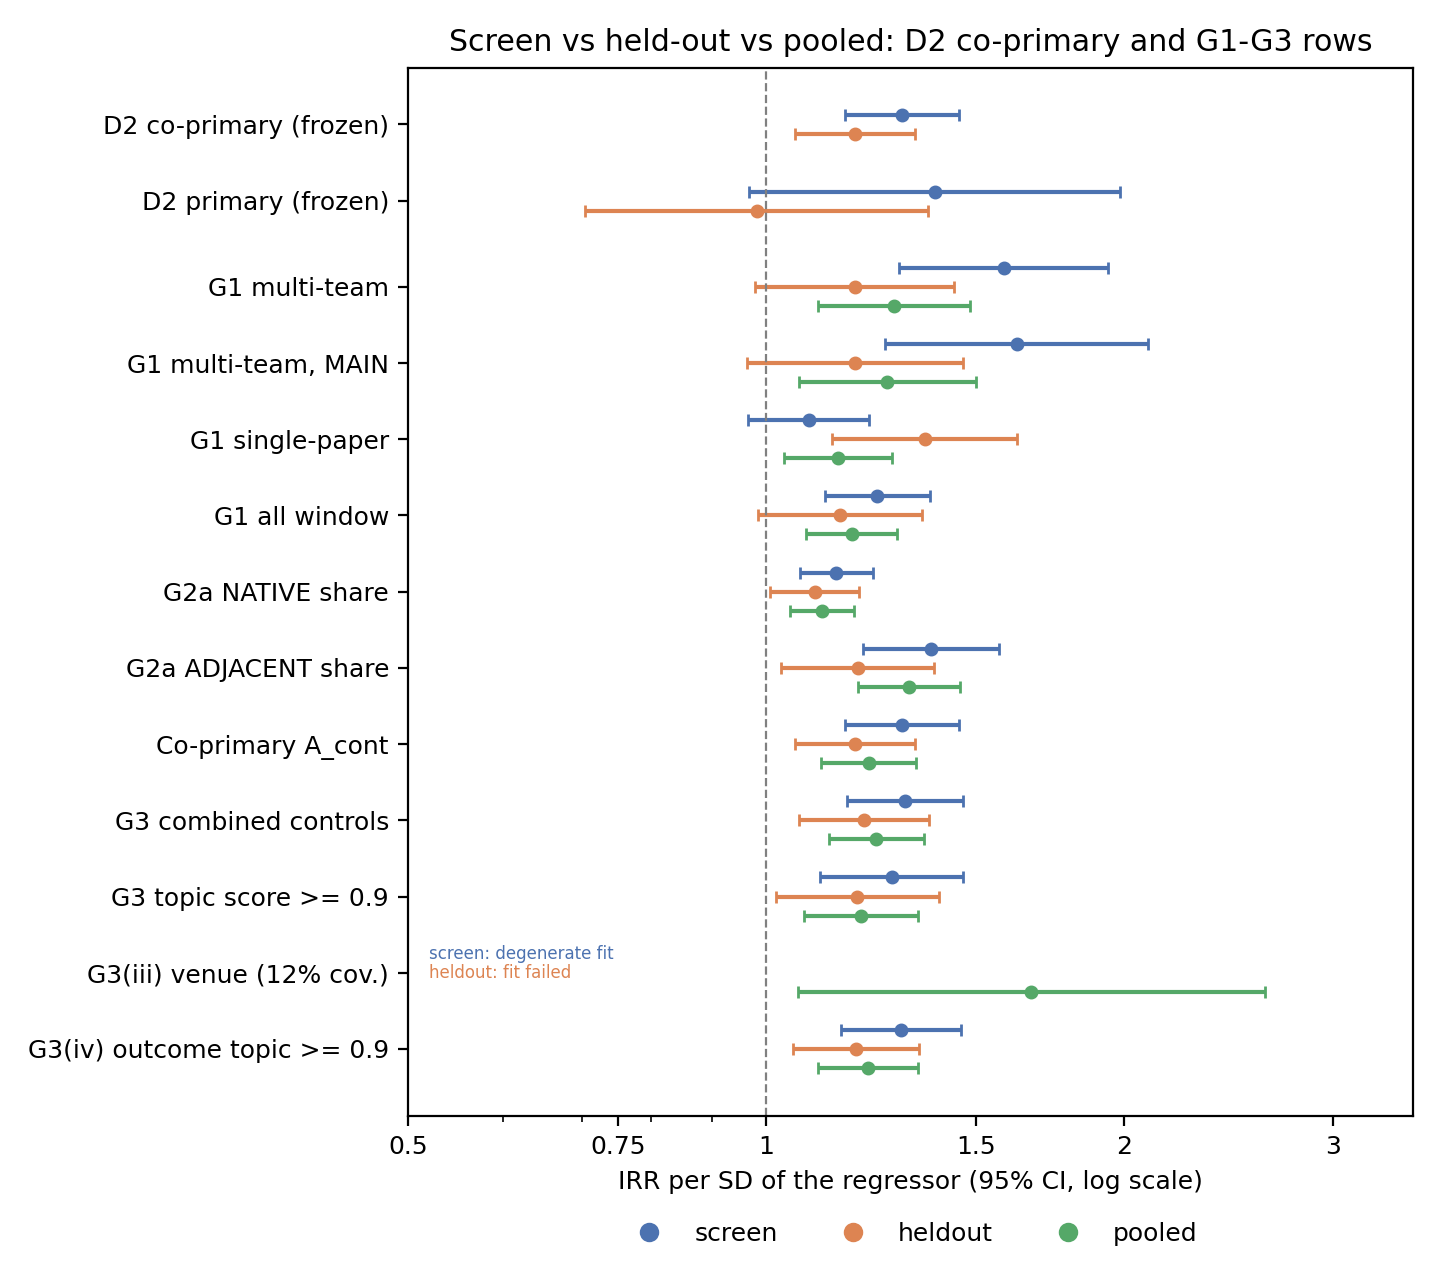

figures/F2_G2_threshold_heatmap.png


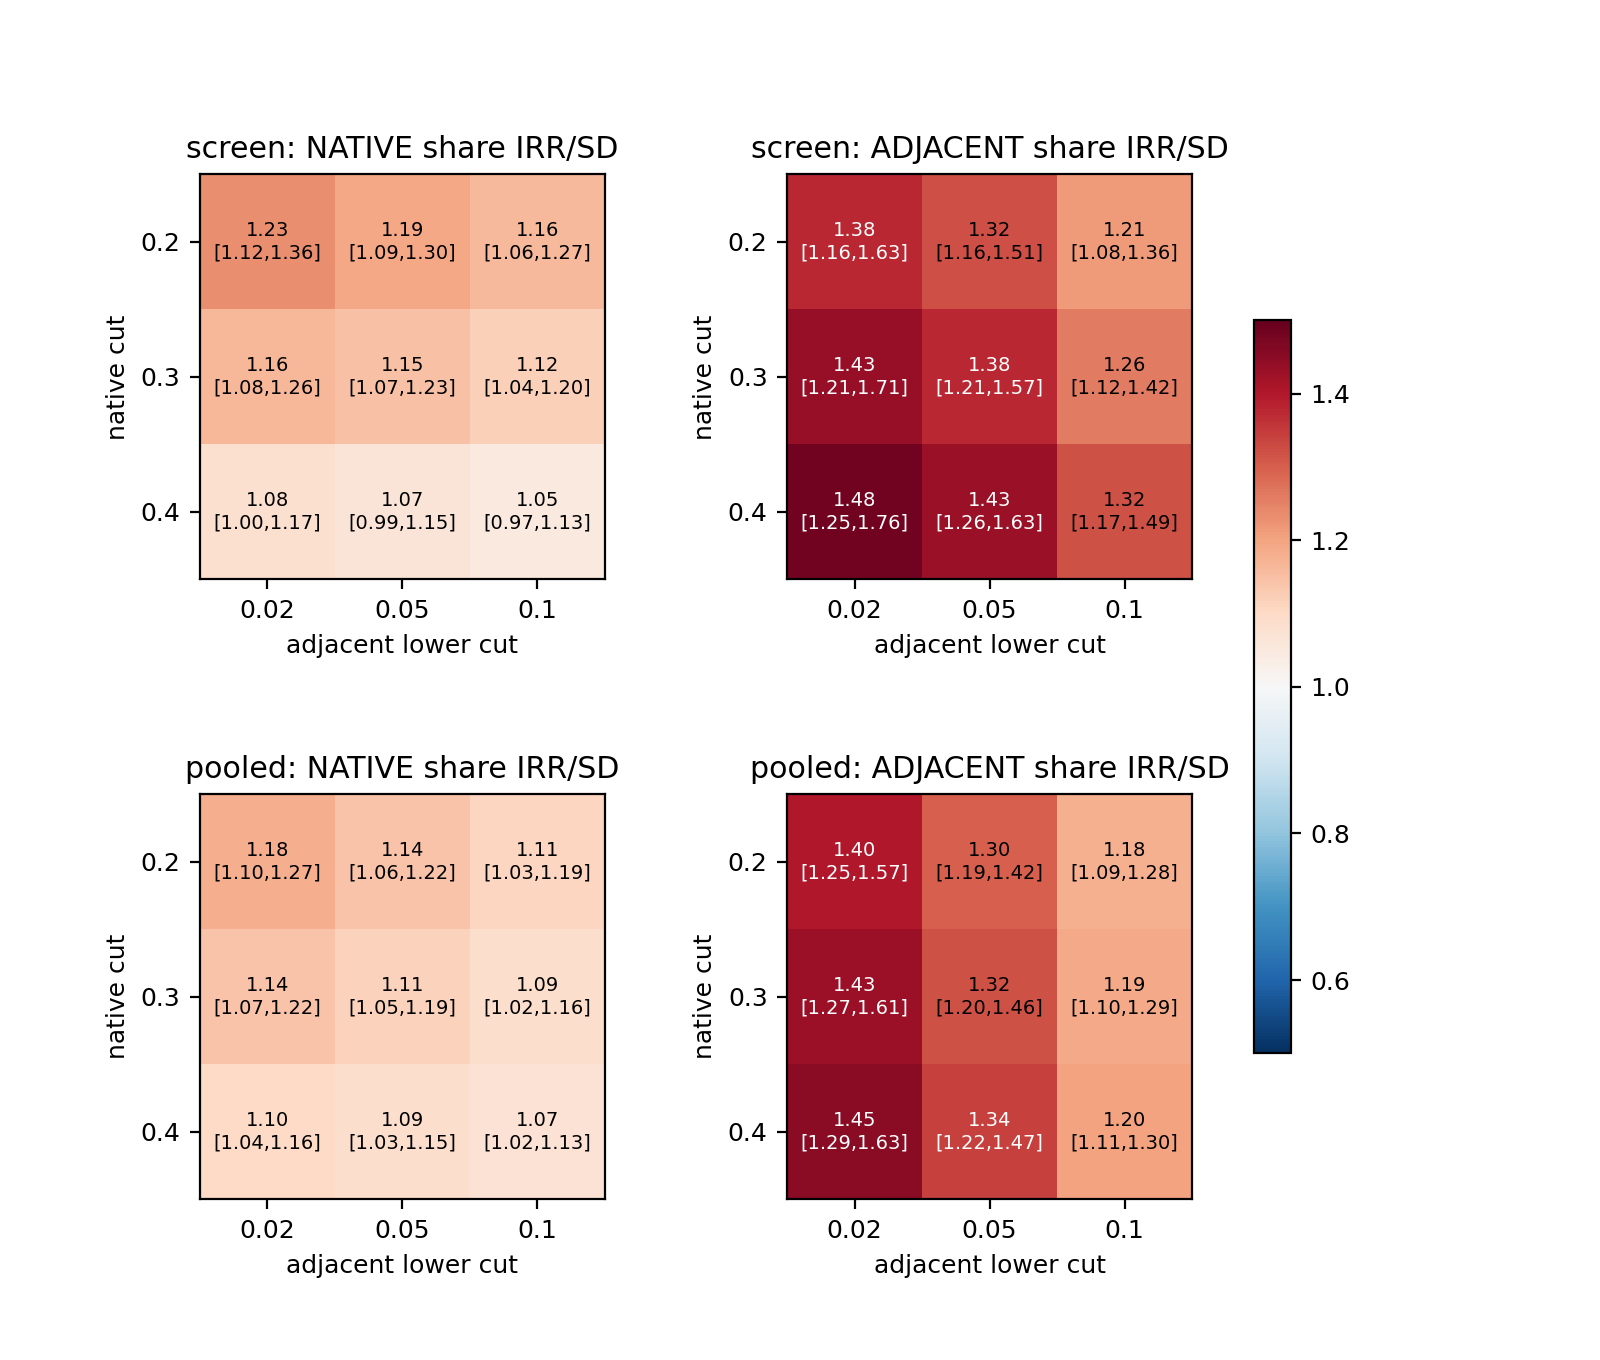

figures/F3_placebo_host.png


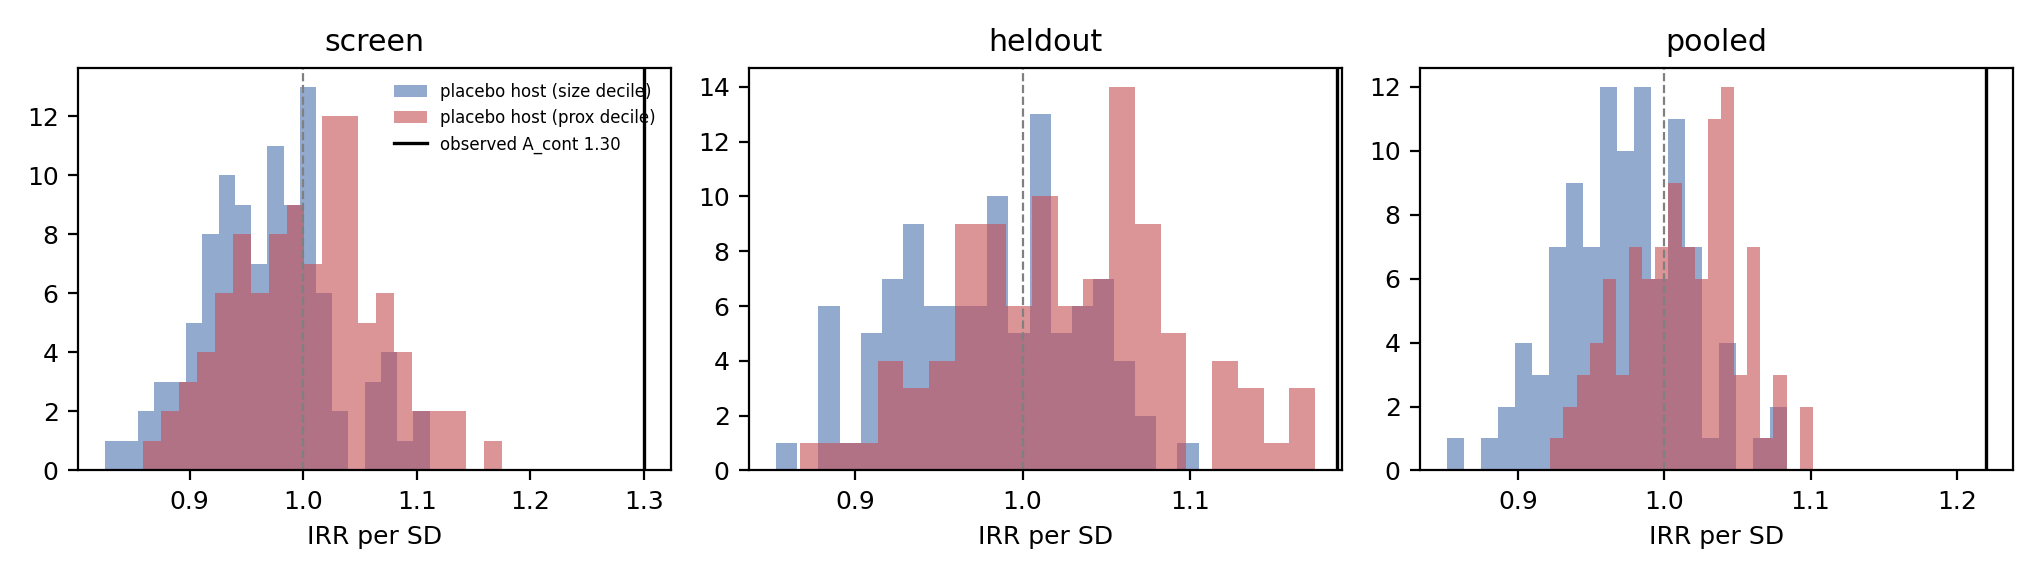

figures/F4_G1_multi_vs_single.png


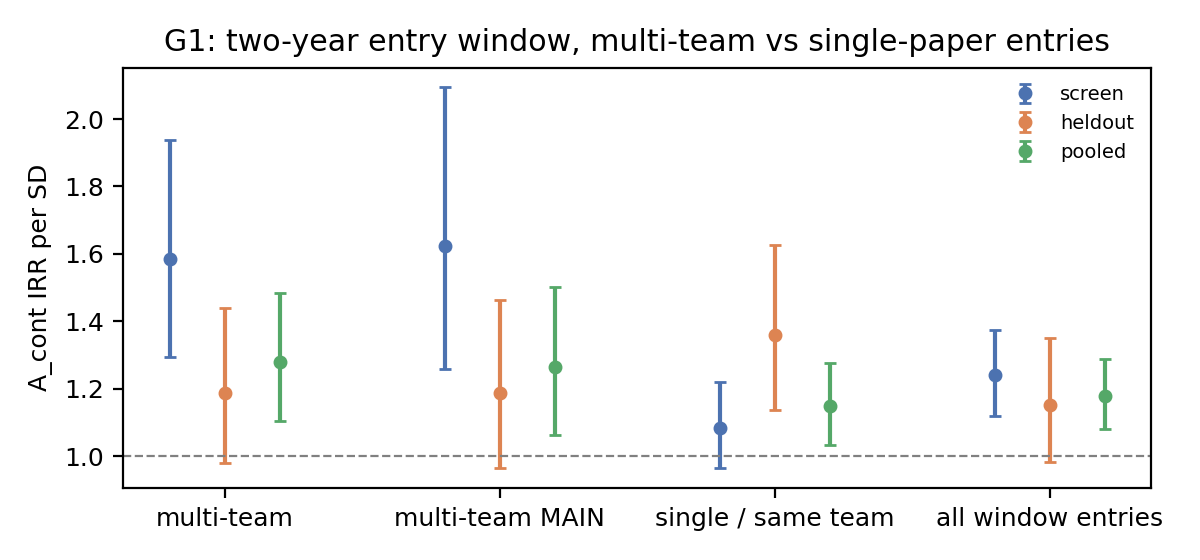

In [18]:
for f in out["metadata"]["figures"]:
    print(f)
    display(Image(str(WS / f), width=720))